## Hedge Fund Quant Pipeline
**Stages:** Raw Prices → Returns → Features → Signal → Portfolio → Risk → Backtest

---
| Parameter | Value |
|---|---|
| Universe | AAPL, MSFT, GOOGL, AMZN, JPM, GS, XOM, CVX, SPY |
| Period | 2018-01-01 to 2024-12-31 |
| Transaction cost | 10 bps per trade |
| Signal | Composite: Momentum + Z-score + RSI + Low-vol |

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ---- Global plot style ----
plt.rcParams.update({
    'figure.facecolor'   : '#0f1117',
    'axes.facecolor'     : '#161b22',
    'axes.edgecolor'     : '#30363d',
    'axes.labelcolor'    : '#c9d1d9',
    'axes.titlecolor'    : '#f0f6fc',
    'axes.titlesize'     : 13,
    'axes.labelsize'     : 10,
    'axes.grid'          : True,
    'grid.color'         : '#21262d',
    'grid.linewidth'     : 0.6,
    'xtick.color'        : '#8b949e',
    'ytick.color'        : '#8b949e',
    'legend.facecolor'   : '#161b22',
    'legend.edgecolor'   : '#30363d',
    'legend.labelcolor'  : '#c9d1d9',
    'legend.fontsize'    : 9,
    'lines.linewidth'    : 1.6,
    'font.family'        : 'DejaVu Sans',
})

# Colour palette
C = dict(
    blue   = '#58a6ff',
    navy   = '#1f6feb',
    green  = '#3fb950',
    red    = '#f85149',
    orange = '#e3b341',
    purple = '#bc8cff',
    gray   = '#8b949e',
    white  = '#f0f6fc',
)

print('Imports OK')

Imports OK


## Raw Price Data
Download adjusted OHLCV for the universe and build a clean price matrix.

Universe: 9 assets | 1760 trading days
Date range: 2018-01-02 to 2024-12-30


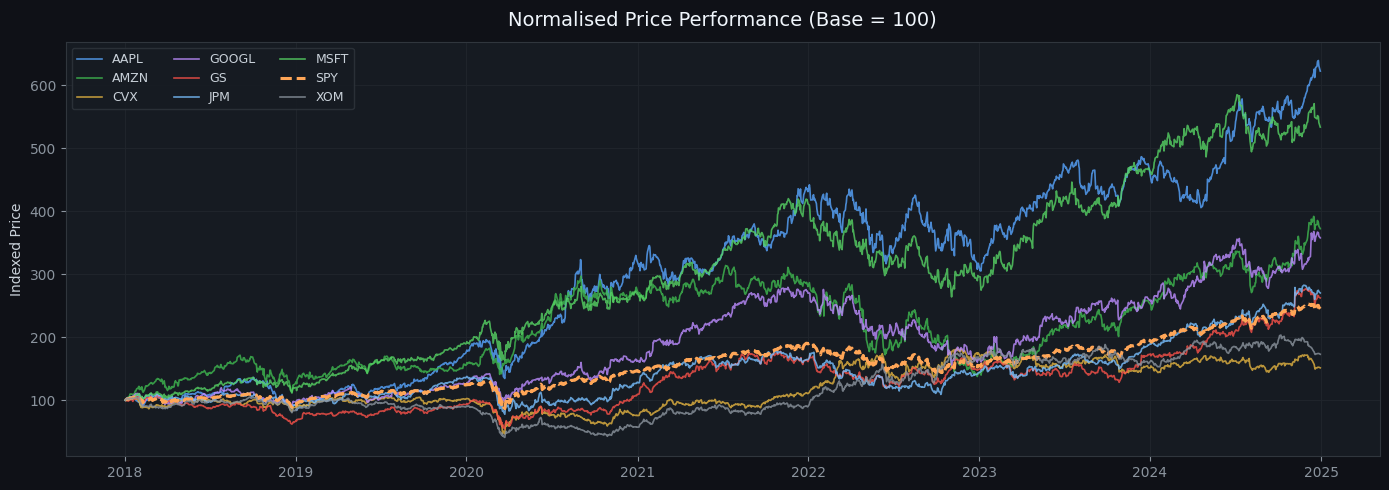

In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'GS', 'XOM', 'CVX', 'SPY']
START, END = '2018-01-01', '2024-12-31'

raw    = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].dropna(how='all')
volume = raw['Volume'].dropna(how='all')

prices = prices.ffill(limit=5)
prices = prices.loc[:, prices.isna().mean() < 0.05]

print(f'Universe: {prices.shape[1]} assets | {prices.shape[0]} trading days')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')

# Normalised price chart
fig, ax = plt.subplots(figsize=(14, 5))
norm = prices / prices.iloc[0] * 100
spy_norm = norm['SPY']

colors_list = [C['blue'], C['green'], C['orange'], C['purple'],
               C['red'], '#79c0ff', '#56d364', '#ffa657', C['gray']]

for i, col in enumerate(norm.columns):
    lw = 2.2 if col == 'SPY' else 1.2
    ls = '--' if col == 'SPY' else '-'
    alpha = 1.0 if col == 'SPY' else 0.8
    ax.plot(norm.index, norm[col], lw=lw, ls=ls, alpha=alpha,
            color=colors_list[i], label=col)

ax.set_title('Normalised Price Performance (Base = 100)', fontsize=14, color=C['white'], pad=12)
ax.set_ylabel('Indexed Price')
ax.set_xlabel('')
ax.legend(ncol=3, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%d'))
plt.tight_layout()
plt.show()

## Returns
Log returns for time-series models; simple returns for portfolio aggregation.

        Ann. Return  Ann. Vol  Sharpe
Ticker                               
AAPL          0.262     0.306   0.857
AMZN          0.188     0.344   0.547
CVX           0.059     0.324   0.183
GOOGL         0.183     0.308   0.592
GS            0.138     0.309   0.447
JPM           0.142     0.295   0.482
MSFT          0.240     0.289   0.830
SPY           0.128     0.195   0.657
XOM           0.079     0.310   0.253


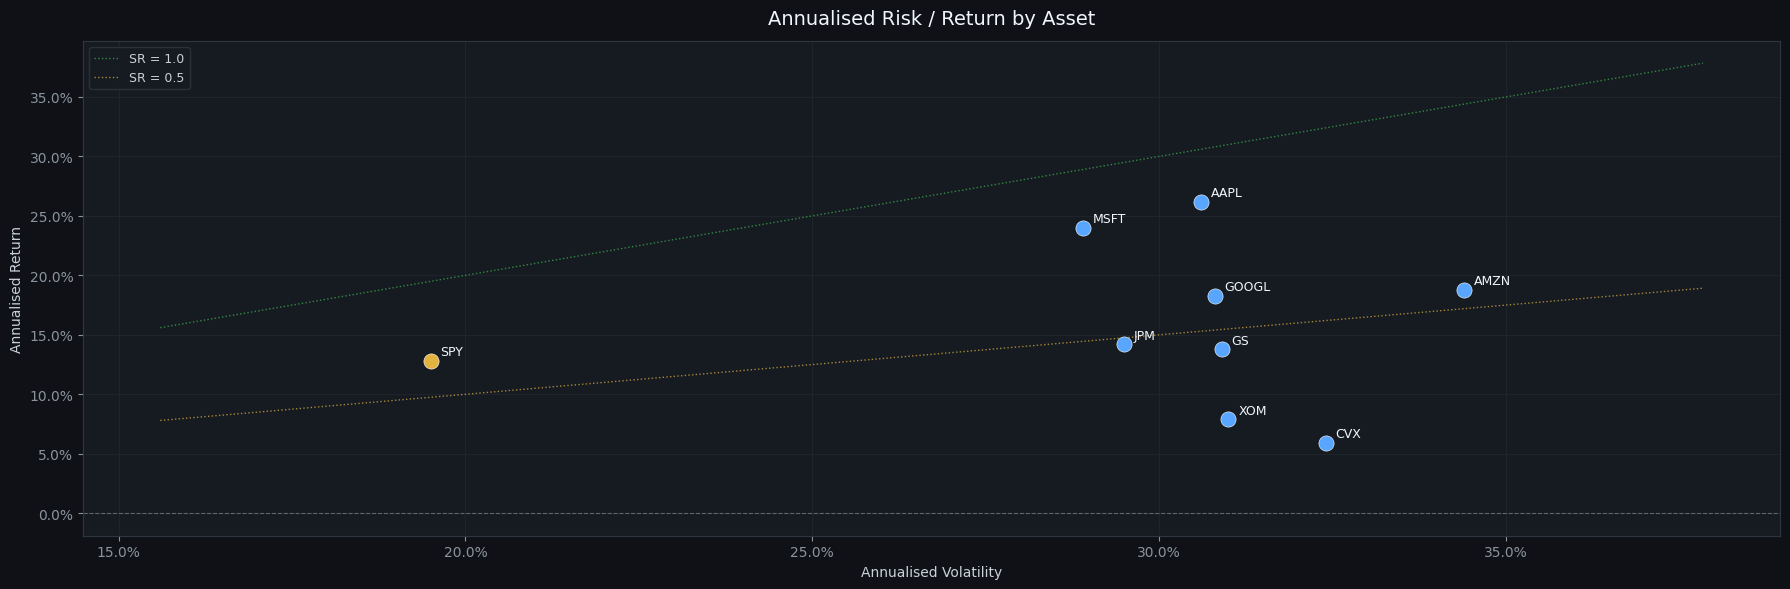

In [4]:
log_ret = np.log(prices).diff().dropna()
sim_ret = prices.pct_change().dropna()

ret_1m  = log_ret.rolling(21).sum()
ret_3m  = log_ret.rolling(63).sum()
ret_12m = log_ret.rolling(252).sum()

spy_ret = log_ret['SPY']
excess  = log_ret.drop(columns='SPY').sub(spy_ret, axis=0)

ann_ret = log_ret.mean() * 252
ann_vol = log_ret.std()  * np.sqrt(252)
sharpe  = ann_ret / ann_vol

stats = pd.DataFrame({'Ann. Return': ann_ret, 'Ann. Vol': ann_vol, 'Sharpe': sharpe}).round(3)
print(stats.to_string())

# Risk/return scatter
fig, ax = plt.subplots(figsize=(18, 6))
for i, tkr in enumerate(stats.index):
    x = stats.loc[tkr, 'Ann. Vol']
    y = stats.loc[tkr, 'Ann. Return']
    color = C['orange'] if tkr == 'SPY' else C['blue']
    ax.scatter(x, y, s=120, color=color, zorder=5, edgecolors='white', linewidths=0.4)
    ax.annotate(tkr, (x, y), textcoords='offset points', xytext=(7, 4),
                fontsize=9, color=C['white'])

ax.axhline(0, color=C['gray'], lw=0.8, ls='--', alpha=0.6)
vols = np.linspace(stats['Ann. Vol'].min()*0.8, stats['Ann. Vol'].max()*1.1, 200)
for sr, col, lbl in [(1.0, C['green'], 'SR = 1.0'), (0.5, C['orange'], 'SR = 0.5')]:
    ax.plot(vols, vols * sr, lw=1, ls=':', color=col, alpha=0.7, label=lbl)

ax.set_title('Annualised Risk / Return by Asset', fontsize=14, color=C['white'], pad=12)
ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Return')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

## Feature Engineering
Momentum, volatility, Z-score, RSI, Bollinger Band position - then cross-sectionally ranked.

Features built: 12
Start date: 2019-01-03 | Shape: (1508, 8)


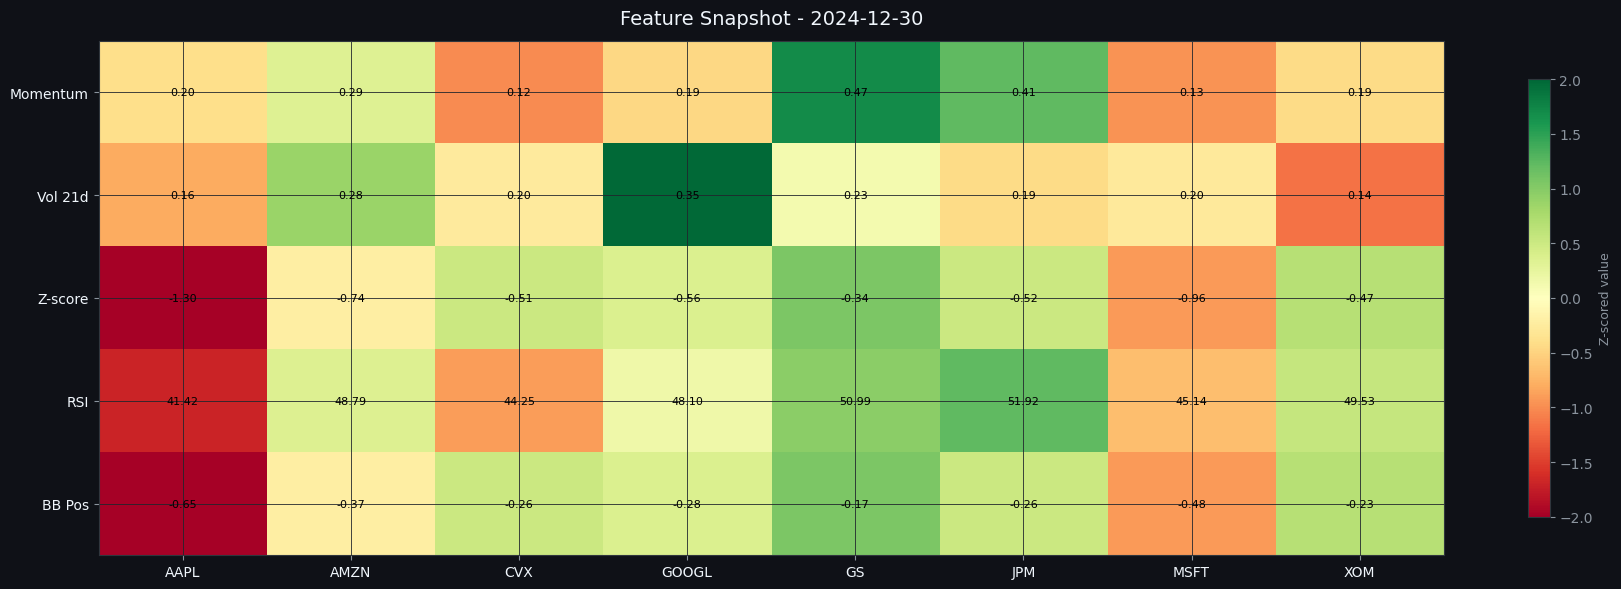

In [7]:
assets = log_ret.drop(columns='SPY')
feat   = {}

# Momentum (12-1)
feat['mom_12_1'] = ret_12m.drop(columns='SPY') - ret_1m.drop(columns='SPY')

# Realised vol
feat['vol_21d'] = assets.rolling(21).std() * np.sqrt(252)
feat['vol_63d'] = assets.rolling(63).std() * np.sqrt(252)

# Z-score
roll_mean = assets.rolling(63).mean()
roll_std  = assets.rolling(63).std()
feat['z_score'] = (assets - roll_mean) / roll_std

# RSI
def rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    return 100 - (100 / (1 + gain / loss))

feat['rsi_14'] = assets.apply(rsi)

# Bollinger Band position
bb_upper = roll_mean + 2 * roll_std
bb_lower = roll_mean - 2 * roll_std
feat['bb_pos'] = (assets - bb_lower) / (bb_upper - bb_lower) * 2 - 1

# Cross-sectional ranks
feat_ranked = {
    name + '_rank': df.rank(axis=1, pct=True)
    for name, df in feat.items()
}
feat.update(feat_ranked)

first_valid = max(df.dropna().index[0] for df in feat.values())
feat = {name: df.loc[first_valid:] for name, df in feat.items()}

print(f'Features built: {len(feat)}')
print(f'Start date: {first_valid.date()} | Shape: {next(iter(feat.values())).shape}')

# Feature heatmap for latest date
base_feats  = ['mom_12_1', 'vol_21d', 'z_score', 'rsi_14', 'bb_pos']
latest_snap = pd.DataFrame(
    {k: feat[k].iloc[-1] for k in base_feats}
).T
latest_snap.index = ['Momentum', 'Vol 21d', 'Z-score', 'RSI', 'BB Pos']

fig, ax = plt.subplots(figsize=(18, 6))
snap_norm = latest_snap.apply(lambda r: (r - r.mean()) / (r.std() + 1e-9), axis=1)
im = ax.imshow(snap_norm.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(snap_norm.columns)))
ax.set_xticklabels(snap_norm.columns, fontsize=10, color=C['white'])
ax.set_yticks(range(len(snap_norm.index)))
ax.set_yticklabels(snap_norm.index, fontsize=10, color=C['white'])
for i in range(snap_norm.shape[0]):
    for j in range(snap_norm.shape[1]):
        ax.text(j, i, f'{latest_snap.values[i, j]:.2f}',
                ha='center', va='center', fontsize=8, color='black')
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('Z-scored value', color=C['gray'], fontsize=9)
cbar.ax.yaxis.set_tick_params(color=C['gray'])
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=C['gray'])
ax.set_title(f'Feature Snapshot - {feat["mom_12_1"].index[-1].date()}',
             fontsize=14, color=C['white'], pad=12)
plt.tight_layout()
plt.show()

## Signal Model
Weighted composite of ranked features, then cross-sectionally z-scored to remove market drift.

Signal matrix: (1508, 8)
Ticker       AAPL   AMZN    CVX  GOOGL     GS    JPM   MSFT    XOM
Date                                                              
2024-12-26 -0.553  1.291 -1.429 -1.199  0.922  0.830  0.046  0.092
2024-12-27  1.046  0.613 -1.911 -0.289  0.180  0.974  0.252 -0.866
2024-12-30  2.092  0.279 -1.116 -0.930 -0.418  0.325  0.139 -0.372


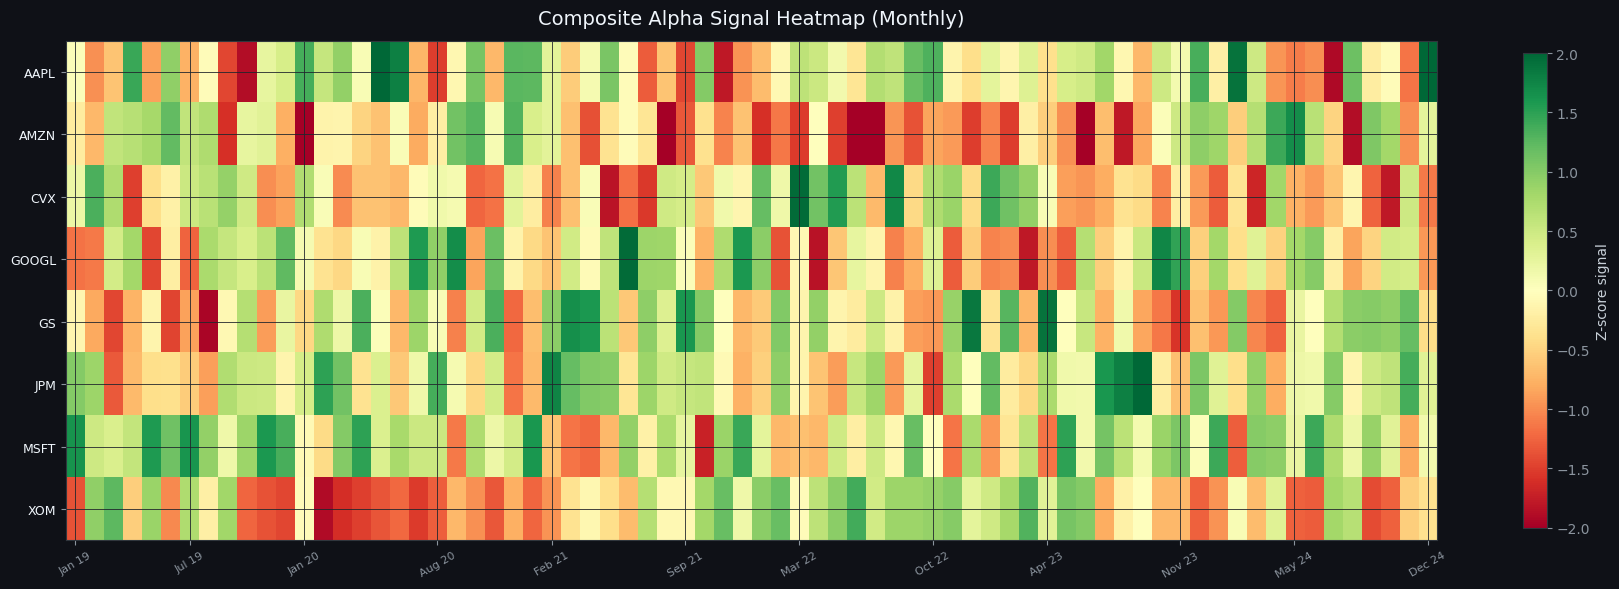

In [8]:
signal_weights = {
    'mom_12_1_rank' : +0.35,
    'z_score_rank'  : -0.25,
    'rsi_14_rank'   : -0.20,
    'vol_21d_rank'  : -0.20,
}

composite = sum(feat[sig] * w for sig, w in signal_weights.items())
signal_z  = composite.sub(composite.mean(axis=1), axis=0)
signal_z  = signal_z.div(composite.std(axis=1),   axis=0)

print(f'Signal matrix: {signal_z.shape}')
print(signal_z.tail(3).round(3))

# Signal heatmap over time (monthly sampled)
monthly = signal_z.resample('ME').last()

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(monthly.T.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
x_ticks = np.linspace(0, len(monthly) - 1, 12, dtype=int)
ax.set_xticks(x_ticks)
ax.set_xticklabels([monthly.index[i].strftime('%b %y') for i in x_ticks],
                   fontsize=8, color=C['gray'], rotation=30)
ax.set_yticks(range(len(monthly.columns)))
ax.set_yticklabels(monthly.columns, fontsize=9, color=C['white'])
plt.colorbar(im, ax=ax, label='Z-score signal', shrink=0.95)
ax.set_title('Composite Alpha Signal Heatmap (Monthly)', fontsize=14, color=C['white'], pad=12)
plt.tight_layout()
plt.show()

## Portfolio Construction
Dollar-neutral long/short quintile book with position limits and turnover smoothing.

Mean daily turnover : 25.08%
Ann. two-way        : 6320%


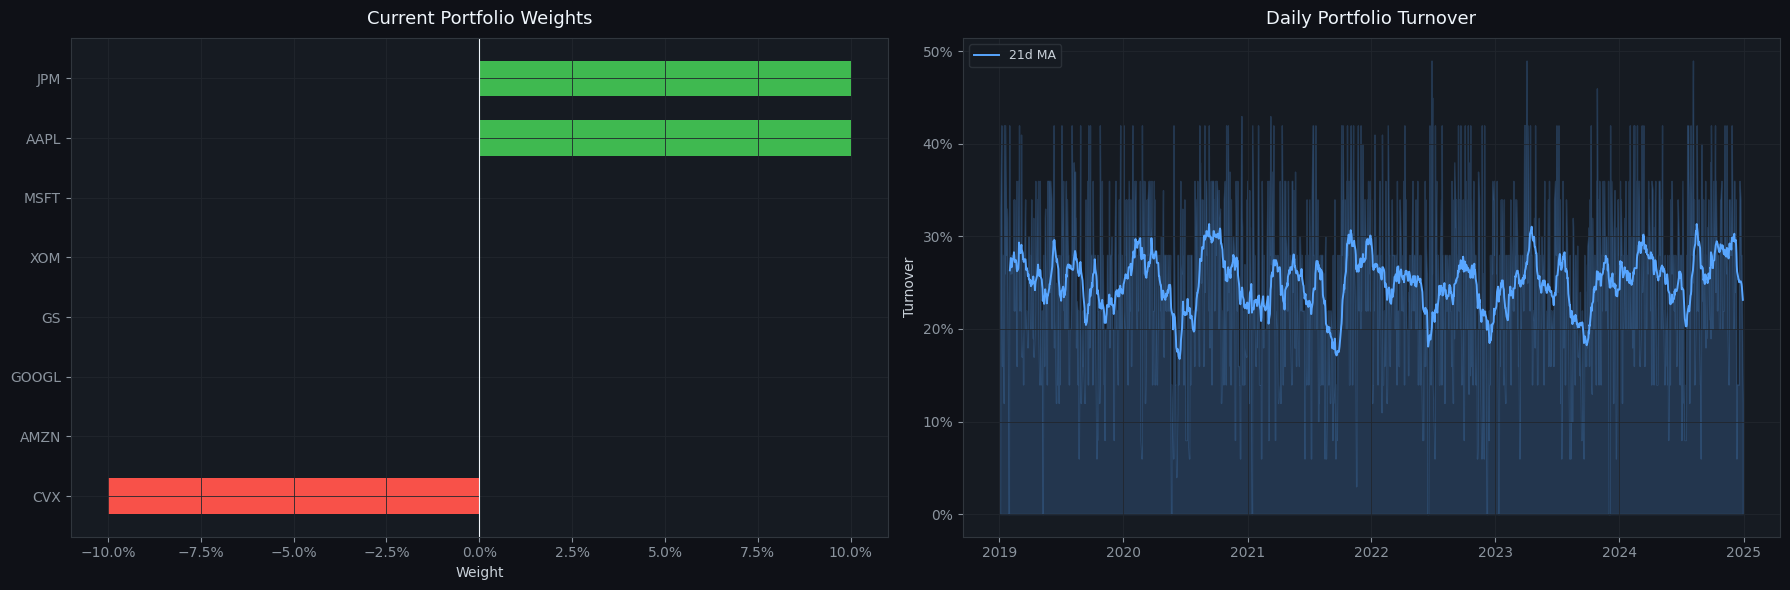

In [9]:
QUINTILE        = 0.20
MAX_SINGLE_NAME = 0.10
BLEND           = 0.70

long_mask  = signal_z.rank(axis=1, pct=True) > (1 - QUINTILE)
short_mask = signal_z.rank(axis=1, pct=True) < QUINTILE

raw_weights = pd.DataFrame(0.0, index=signal_z.index, columns=signal_z.columns)
raw_weights[long_mask]  =  1.0
raw_weights[short_mask] = -1.0

long_sum  = raw_weights.clip(lower=0).sum(axis=1).replace(0, np.nan)
short_sum = raw_weights.clip(upper=0).abs().sum(axis=1).replace(0, np.nan)

weights = raw_weights.copy()
weights[raw_weights > 0] = raw_weights[raw_weights > 0].div(long_sum,  axis=0)
weights[raw_weights < 0] = raw_weights[raw_weights < 0].div(short_sum, axis=0)
weights = weights.clip(-MAX_SINGLE_NAME, MAX_SINGLE_NAME)

weights_smooth = weights * BLEND + weights.shift(1).fillna(0) * (1 - BLEND)

turnover = weights_smooth.diff().abs().sum(axis=1)
print(f'Mean daily turnover : {turnover.mean():.2%}')
print(f'Ann. two-way        : {turnover.mean()*252:.0%}')

# Weight distribution (latest)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

w_latest = weights_smooth.iloc[-1].sort_values()
colors_bar = [C['red'] if v < 0 else C['green'] for v in w_latest]
ax1.barh(w_latest.index, w_latest.values, color=colors_bar, edgecolor='none', height=0.6)
ax1.axvline(0, color=C['white'], lw=0.8)
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_title('Current Portfolio Weights', fontsize=13, color=C['white'], pad=10)
ax1.set_xlabel('Weight')

ax2.plot(turnover.rolling(21).mean(), color=C['blue'], lw=1.4, label='21d MA')
ax2.fill_between(turnover.index, turnover, alpha=0.2, color=C['blue'])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_title('Daily Portfolio Turnover', fontsize=13, color=C['white'], pad=10)
ax2.set_ylabel('Turnover')
ax2.legend()

plt.tight_layout()
plt.show()

## Risk Management
VaR, CVaR, drawdown analysis, Sharpe, Sortino, Calmar and full risk report.


Risk Report
------------------------------------------
  Annualised Return     :    5.10%
  Annualised Vol        :    4.44%
  Sharpe Ratio          :     1.15
  Sortino Ratio         :     1.65
  Max Drawdown          :   -4.45%
  Calmar Ratio          :     1.15
  95% 1-day VaR         :    0.42%
  99% 1-day VaR         :    0.74%
  95% CVaR (ES)         :    0.63%
  Hit Rate              :   53.18%
  Profit Factor         :     1.08
------------------------------------------


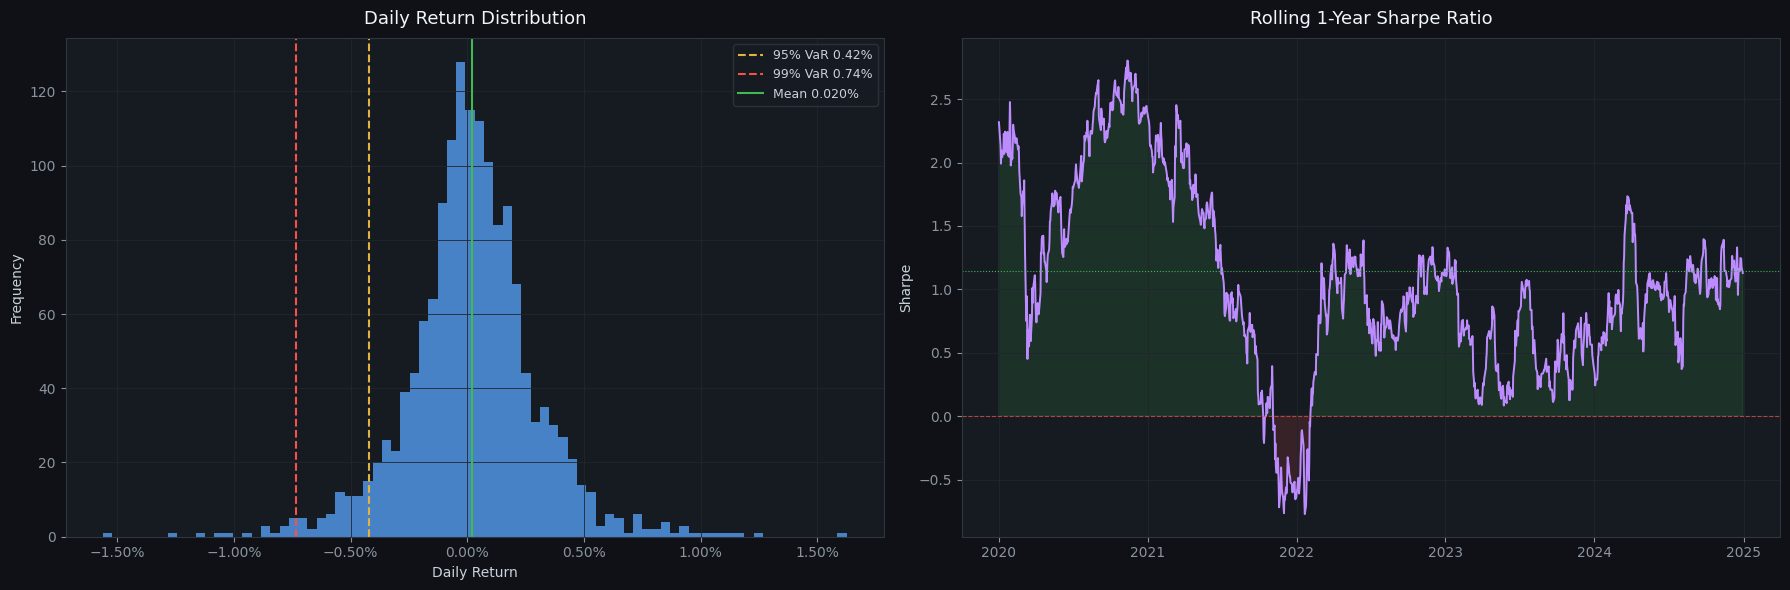

In [10]:
port_ret = (weights_smooth.shift(1) * sim_ret.drop(columns='SPY')).sum(axis=1)
port_ret = port_ret.loc[weights_smooth.index].dropna()

ann_ret_p  = port_ret.mean() * 252
ann_vol_p  = port_ret.std()  * np.sqrt(252)
sharpe_p   = ann_ret_p / ann_vol_p
downside_v = port_ret[port_ret < 0].std() * np.sqrt(252)
sortino_p  = ann_ret_p / downside_v if downside_v != 0 else np.nan

nav    = (1 + port_ret).cumprod()
peak   = nav.cummax()
dd     = nav / peak - 1
max_dd = dd.min()
calmar = ann_ret_p / abs(max_dd) if max_dd != 0 else np.nan

VaR_95  = -np.percentile(port_ret, 5)
VaR_99  = -np.percentile(port_ret, 1)
CVaR_95 = -port_ret[port_ret < -VaR_95].mean()

hit_rate      = (port_ret > 0).mean()
avg_win       = port_ret[port_ret > 0].mean()
avg_loss      = port_ret[port_ret < 0].mean()
profit_factor = abs(avg_win / avg_loss) if avg_loss != 0 else np.nan

risk_report = {
    'Annualised Return'  : f'{ann_ret_p:.2%}',
    'Annualised Vol'     : f'{ann_vol_p:.2%}',
    'Sharpe Ratio'       : f'{sharpe_p:.2f}',
    'Sortino Ratio'      : f'{sortino_p:.2f}',
    'Max Drawdown'       : f'{max_dd:.2%}',
    'Calmar Ratio'       : f'{calmar:.2f}',
    '95% 1-day VaR'      : f'{VaR_95:.2%}',
    '99% 1-day VaR'      : f'{VaR_99:.2%}',
    '95% CVaR (ES)'      : f'{CVaR_95:.2%}',
    'Hit Rate'           : f'{hit_rate:.2%}',
    'Profit Factor'      : f'{profit_factor:.2f}',
}

print('\nRisk Report')
print('-' * 42)
for k, v in risk_report.items():
    print(f'  {k:<22}: {v:>8}')
print('-' * 42)

# Return distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.hist(port_ret, bins=80, color=C['blue'], alpha=0.75, edgecolor='none')
ax.axvline(-VaR_95, color=C['orange'], lw=1.5, ls='--', label=f'95% VaR {VaR_95:.2%}')
ax.axvline(-VaR_99, color=C['red'],    lw=1.5, ls='--', label=f'99% VaR {VaR_99:.2%}')
ax.axvline(port_ret.mean(), color=C['green'], lw=1.5, label=f'Mean {port_ret.mean():.3%}')
ax.set_title('Daily Return Distribution', fontsize=13, color=C['white'], pad=10)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()

ax = axes[1]
rolling_sharpe = (port_ret.rolling(252).mean() * 252) / (port_ret.rolling(252).std() * np.sqrt(252))
ax.plot(rolling_sharpe, color=C['purple'], lw=1.4)
ax.axhline(0,          color=C['red'],   lw=0.8, ls='--', alpha=0.7)
ax.axhline(sharpe_p,   color=C['green'], lw=0.8, ls=':')
ax.fill_between(rolling_sharpe.index, rolling_sharpe, 0,
                where=(rolling_sharpe >= 0), alpha=0.15, color=C['green'])
ax.fill_between(rolling_sharpe.index, rolling_sharpe, 0,
                where=(rolling_sharpe <  0), alpha=0.15, color=C['red'])
ax.set_title('Rolling 1-Year Sharpe Ratio', fontsize=13, color=C['white'], pad=10)
ax.set_ylabel('Sharpe')

plt.tight_layout()
plt.show()

## Execution & Backtest
Apply transaction costs, then plot the full equity curve dashboard.

Gross return     : 5.10%
Transaction cost : 6.32%
Net return       : -1.22%
Net Sharpe       : -0.28


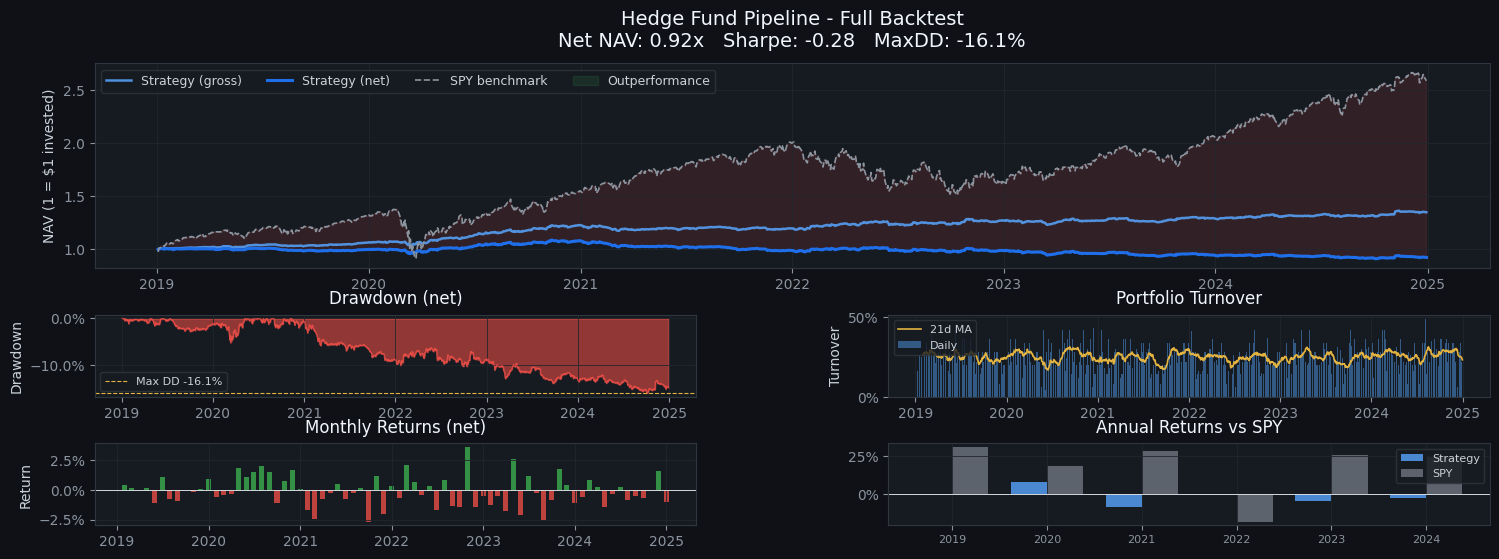

Backtest complete.


In [12]:
BPS = 0.0010

daily_turnover = weights_smooth.diff().abs().sum(axis=1)
cost           = (daily_turnover * BPS).reindex(port_ret.index).fillna(0)
port_ret_net   = port_ret - cost

spy_nav   = (1 + sim_ret['SPY'].reindex(port_ret.index).fillna(0)).cumprod()
gross_nav = (1 + port_ret).cumprod()
net_nav   = (1 + port_ret_net).cumprod()
dd_final  = net_nav / net_nav.cummax() - 1

net_ann_ret = port_ret_net.mean() * 252
cost_drag   = ann_ret_p - net_ann_ret
net_sharpe  = net_ann_ret / (port_ret_net.std() * np.sqrt(252))

print(f'Gross return     : {ann_ret_p:.2%}')
print(f'Transaction cost : {cost_drag:.2%}')
print(f'Net return       : {net_ann_ret:.2%}')
print(f'Net Sharpe       : {net_sharpe:.2f}')

# Full dashboard
fig = plt.figure(figsize=(18, 6), facecolor='#0f1117')
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        height_ratios=[3, 1.2, 1.2],
                        hspace=0.38, wspace=0.32)

ax_nav  = fig.add_subplot(gs[0, :])
ax_dd   = fig.add_subplot(gs[1, 0])
ax_to   = fig.add_subplot(gs[1, 1])
ax_mret = fig.add_subplot(gs[2, 0])
ax_yret = fig.add_subplot(gs[2, 1])

# NAV panel
ax_nav.plot(gross_nav, color=C['blue'],   lw=1.8, label='Strategy (gross)', alpha=0.85)
ax_nav.plot(net_nav,   color=C['navy'],   lw=2.2, label='Strategy (net)')
ax_nav.plot(spy_nav,   color=C['gray'],   lw=1.2, ls='--', label='SPY benchmark')
ax_nav.fill_between(net_nav.index, net_nav, spy_nav,
                    where=(net_nav >= spy_nav), alpha=0.12,
                    color=C['green'], label='Outperformance')
ax_nav.fill_between(net_nav.index, net_nav, spy_nav,
                    where=(net_nav < spy_nav),  alpha=0.12, color=C['red'])

final_str = (f'Net NAV: {net_nav.iloc[-1]:.2f}x   '
             f'Sharpe: {net_sharpe:.2f}   '
             f'MaxDD: {dd_final.min():.1%}')
ax_nav.set_title(f'Hedge Fund Pipeline - Full Backtest\n{final_str}',
                 fontsize=14, color=C['white'], pad=12)
ax_nav.set_ylabel('NAV (1 = $1 invested)')
ax_nav.legend(ncol=4)

# Drawdown panel
ax_dd.fill_between(dd_final.index, dd_final, 0, color=C['red'], alpha=0.55)
ax_dd.plot(dd_final, color=C['red'], lw=0.8, alpha=0.7)
ax_dd.axhline(dd_final.min(), color=C['orange'], lw=0.8, ls='--',
              label=f'Max DD {dd_final.min():.1%}')
ax_dd.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax_dd.set_title('Drawdown (net)', fontsize=12, color=C['white'], pad=8)
ax_dd.set_ylabel('Drawdown')
ax_dd.legend(fontsize=8)

# Turnover panel
ax_to.bar(daily_turnover.index, daily_turnover,
          color=C['blue'], alpha=0.45, width=1, label='Daily')
ax_to.plot(daily_turnover.rolling(21).mean(),
           color=C['orange'], lw=1.2, label='21d MA')
ax_to.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax_to.set_title('Portfolio Turnover', fontsize=12, color=C['white'], pad=8)
ax_to.set_ylabel('Turnover')
ax_to.legend(fontsize=8)

# Monthly returns bar
monthly_ret = port_ret_net.resample('ME').apply(lambda x: (1+x).prod()-1)
bar_colors  = [C['green'] if r >= 0 else C['red'] for r in monthly_ret]
ax_mret.bar(monthly_ret.index, monthly_ret.values,
            color=bar_colors, alpha=0.75, width=20)
ax_mret.axhline(0, color=C['white'], lw=0.6)
ax_mret.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax_mret.set_title('Monthly Returns (net)', fontsize=12, color=C['white'], pad=8)
ax_mret.set_ylabel('Return')

# Annual returns bar
annual_ret    = port_ret_net.resample('YE').apply(lambda x: (1+x).prod()-1)
spy_annual    = sim_ret['SPY'].reindex(port_ret.index).resample('YE').apply(lambda x: (1+x).prod()-1)
years         = [str(y.year) for y in annual_ret.index]
x_pos         = np.arange(len(years))
bar_w         = 0.38
ax_yret.bar(x_pos - bar_w/2, annual_ret.values, bar_w,
            color=C['blue'], alpha=0.8, label='Strategy')
ax_yret.bar(x_pos + bar_w/2, spy_annual.reindex(annual_ret.index).values, bar_w,
            color=C['gray'], alpha=0.6, label='SPY')
ax_yret.set_xticks(x_pos)
ax_yret.set_xticklabels(years, fontsize=8)
ax_yret.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax_yret.axhline(0, color=C['white'], lw=0.6)
ax_yret.set_title('Annual Returns vs SPY', fontsize=12, color=C['white'], pad=8)
ax_yret.legend(fontsize=8)

for ax in [ax_nav, ax_dd, ax_to, ax_mret, ax_yret]:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#8b949e')

plt.savefig('equity_curve.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print('Backtest complete.')